### Etapa 03

- **Objetivos:**
    - ¿Cómo varió mi emoción a lo largo del video?
    - ¿En qué momentos estuve más atento o más fatigado?
    - ¿Qué emoción predominó durante el tiempo de atención baja?
    - ¿Cómo se distribuyeron las emociones?

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

In [2]:
def visualize_emotion_attention(csv_path: str) -> None:
    """
    Genera visualizaciones básicas de emociones y atención a partir del CSV.
    """
    df: pd.DataFrame = pd.read_csv(csv_path)
    df = df.sort_values(by="frame").reset_index(drop=True)

    def parse_timestamp(filename: str) -> datetime:
        # Ejemplo: '2025-04-26_12-45-56.jpg' → datetime(2025, 4, 26, 12, 45, 56)
        base = filename.replace(".jpg", "")
        return datetime.strptime(base, "%Y-%m-%d_%H-%M-%S")

    df["datetime"] = df["frame"].apply(parse_timestamp)
    # print(df["datetime"].head())

    # ──────────── EMOCIÓN DOMINANTE A LO LARGO DEL TIEMPO REAL ─────────────
    # recomendable sns para variables categóricas
    plt.figure(figsize=(12, 4))
    sns.scatterplot(
        data=df,
        x="datetime",               # Usamos marca temporal real
        y="emotion",                # Emoción categórica por frame
        hue="emotion",              # Colores por tipo de emoción
        palette="Set2"              # Paleta de colores suaves y distinguibles
    )
    plt.title("Emoción detectada a lo largo del tiempo real")
    plt.xlabel("Fecha y hora del frame")
    plt.ylabel("Emoción dominante")
    plt.xticks(rotation=45)         # Rota etiquetas para mejor legibilidad
    plt.legend(loc="upper right")
    plt.tight_layout()
    plt.show()

    # ───────────── NIVEL DE ATENCIÓN (EAR) A LO LARGO DEL TIEMPO REAL ─────────────
    plt.figure(figsize=(12, 4))
    # plt.plot ideal para variables continuas
    plt.plot(
        df["datetime"],     # Eje X: tiempo real extraído del nombre del archivo
        df["EAR"],          # Eje Y: Eye Aspect Ratio (atención)
        marker='p',
        linestyle='-',
        color='dodgerblue',
        label="EAR"
    )
    plt.axhline(
        y=0.25,             # Línea de umbral de atención
        color='red',
        linestyle='--',
        label="Umbral atención (0.25)"
    )
    plt.title("Nivel de atención (EAR) a lo largo del tiempo real")
    plt.xlabel("Fecha y hora del frame")
    plt.ylabel("EAR (Eye Aspect Ratio)")
    # ↪ Rota las etiquetas del eje X (fecha y hora) para que no se sobrepongan y sean más legibles.
    plt.xticks(rotation=45)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # ───────────── DISTRIBUCIÓN DE EMOCIONES ─────────────
    plt.figure(figsize=(8, 4))
    emotion_counts = df["emotion"].value_counts()
    # Crear DataFrame a partir del conteo de emociones
    emotion_counts_df = emotion_counts.reset_index()
    emotion_counts_df.columns = ["emotion", "count"]
    plt.figure(figsize=(8, 4))
    sns.barplot(
        data=emotion_counts_df,
        x="emotion",
        y="count",
        hue="emotion",           # asignamos 'hue' para que Seaborn sepa aplicar colores distintos
        palette="Set3",
        dodge=False              # evita que divida las barras
    )
    plt.title("Distribución de emociones detectadas")
    plt.xlabel("Emoción")
    plt.ylabel("Cantidad de frames")
    plt.tight_layout()
    plt.show()

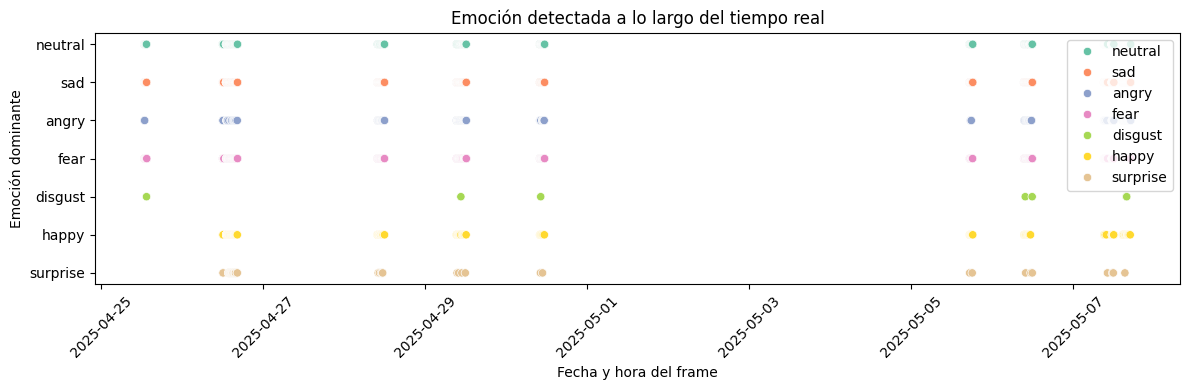

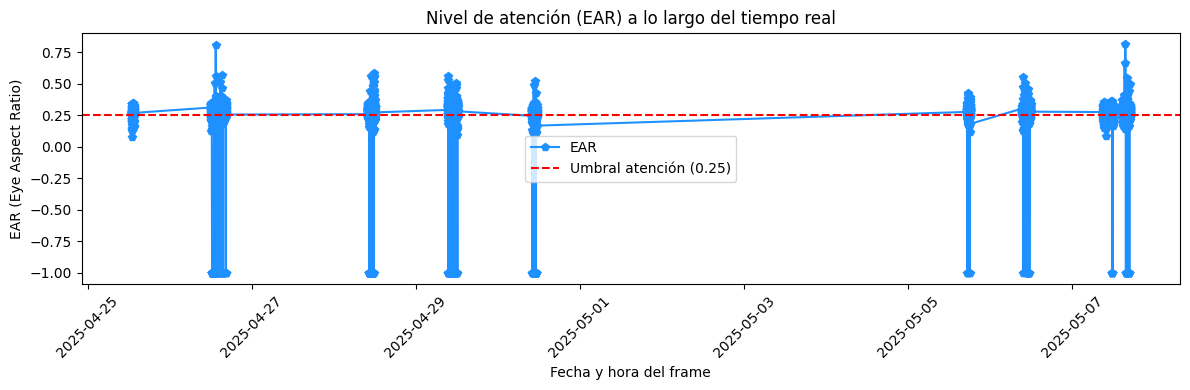

<Figure size 800x400 with 0 Axes>

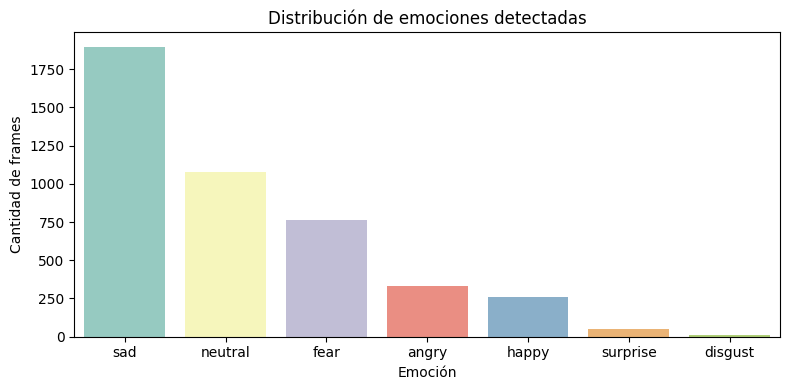

In [3]:
visualize_emotion_attention("emotion_attention_results.csv")

#### Gráfico radial o radial chart

- ***¿Qué tan equilibrado o emocionalmente cargado fue cada día?***

- Un gráfico radial (también llamado “spider chart” o radar chart), donde:
    - Cada eje del gráfico representa una emoción (happy, sad, etc.).
    - La distancia desde el centro indica qué tan frecuente fue esa emoción.
    - Cada línea o contorno representa un día distinto.

- Esta visualización permite comparar días completos en una sola vista intuitiva.



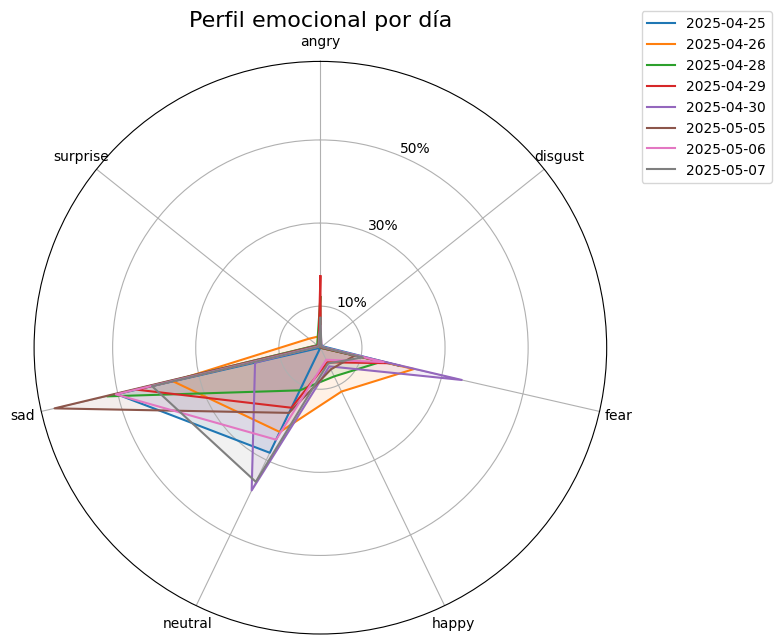

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime

def plot_emotion_radar_by_day(csv_path: str) -> None:
    # Leer archivo CSV
    df = pd.read_csv(csv_path)

    # Convertir nombre del frame a datetime
    df["datetime"] = df["frame"].apply(lambda name: datetime.strptime(name.replace(".jpg", ""), "%Y-%m-%d_%H-%M-%S"))

    # Agregar columna de fecha (sin hora)
    df["date"] = df["datetime"].dt.date

    # Obtener emociones únicas
    emotion_labels = sorted(df["emotion"].dropna().unique())

    # Crear tabla pivote: cuenta de emociones por día
    pivot = df.pivot_table(index="date", columns="emotion", aggfunc="size", fill_value=0)

    # Asegurar que todas las emociones estén como columnas
    for emotion in emotion_labels:
        if emotion not in pivot.columns:
            pivot[emotion] = 0

    pivot = pivot[emotion_labels]  # ordenar columnas

    # Normalizar por día (proporción de cada emoción)
    pivot_norm = pivot.div(pivot.sum(axis=1), axis=0)

    # Radar chart
    num_vars = len(emotion_labels)
    angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
    angles += angles[:1]  # cerrar el círculo

    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

    # Dibujar cada día
    for date, row in pivot_norm.iterrows():
        values = row.tolist()
        values += values[:1]  # cerrar el círculo
        ax.plot(angles, values, label=str(date))
        ax.fill(angles, values, alpha=0.1)

    # Configurar ejes
    ax.set_title("Perfil emocional por día", size=16)
    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(emotion_labels)
    ax.set_yticks([0.1, 0.3, 0.5])
    ax.set_yticklabels(["10%", "30%", "50%"])
    ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1))

    plt.tight_layout()
    plt.show()
    
plot_emotion_radar_by_day("emotion_attention_results.csv")


dasdfasdf

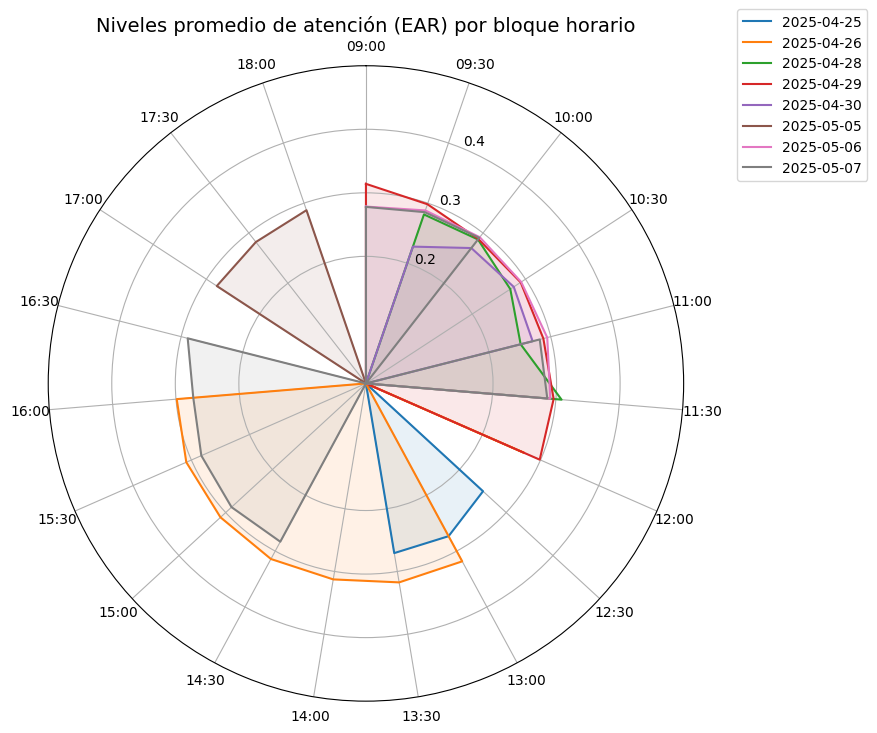

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime

def plot_attention_radar_by_hour(csv_path: str, time_bin_minutes: int = 60) -> None:
    # Leer CSV
    df = pd.read_csv(csv_path)
    df["datetime"] = df["frame"].apply(lambda f: datetime.strptime(f.replace(".jpg", ""), "%Y-%m-%d_%H-%M-%S"))
    df["date"] = df["datetime"].dt.date

    # Crear etiquetas de bloques horarios (por ejemplo, cada 60 minutos)
    df["hour_block"] = df["datetime"].dt.floor(f"{time_bin_minutes}min").dt.strftime("%H:%M")

    # Eliminar filas sin EAR válido
    df = df[df["EAR"] != -1]

    # Calcular EAR promedio por fecha y hora
    pivot = df.pivot_table(index="date", columns="hour_block", values="EAR", aggfunc="mean", fill_value=0)
    pivot = pivot.sort_index(axis=1)  # Ordenar columnas por hora

    # Crear radar chart
    labels = pivot.columns.tolist()
    num_vars = len(labels)
    angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
    angles += angles[:1]  # cerrar círculo

    fig, ax = plt.subplots(figsize=(9, 9), subplot_kw=dict(polar=True))

    # Graficar cada día
    for date, row in pivot.iterrows():
        values = row.tolist()
        values += values[:1]
        ax.plot(angles, values, label=str(date))
        ax.fill(angles, values, alpha=0.1)

    ax.set_title(f"Niveles promedio de atención (EAR) por bloque horario", size=14)
    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels)
    ax.set_yticks([0.2, 0.3, 0.4])
    ax.set_yticklabels(["0.2", "0.3", "0.4"])
    ax.set_ylim(0, max(0.5, pivot.max().max()))
    ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1))
    plt.tight_layout()
    plt.show()

plot_attention_radar_by_hour("emotion_attention_results.csv", time_bin_minutes=30)

/tmp/ipykernel_31181/3523444102.py:37: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend().remove()


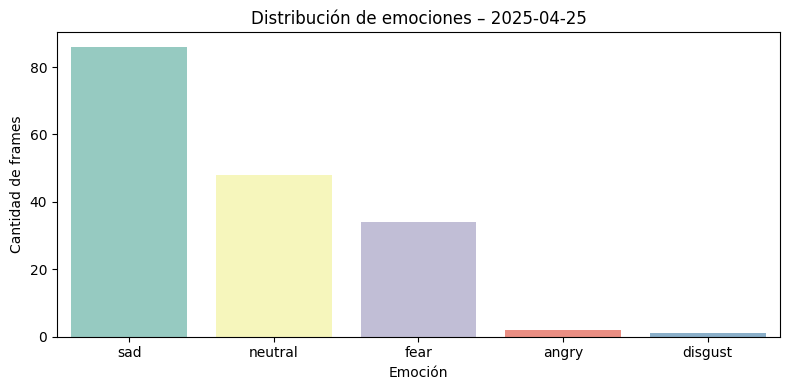

/tmp/ipykernel_31181/3523444102.py:37: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend().remove()


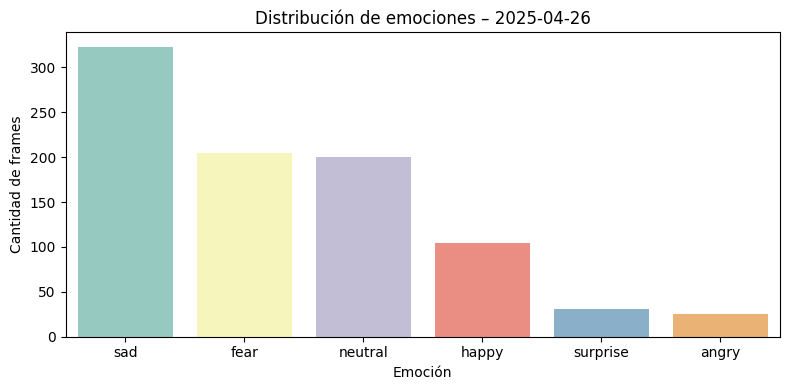

/tmp/ipykernel_31181/3523444102.py:37: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend().remove()


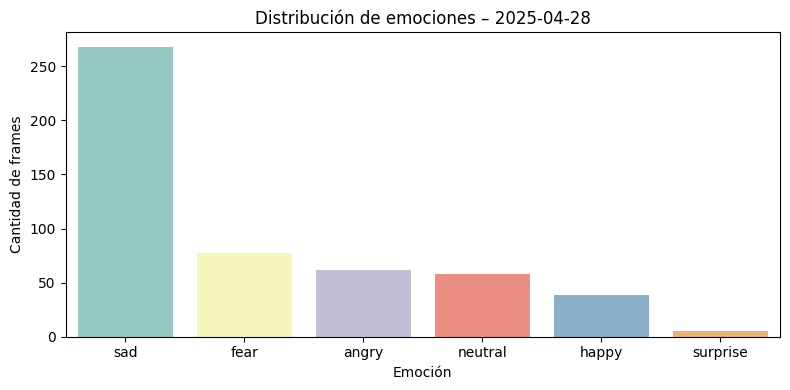

/tmp/ipykernel_31181/3523444102.py:37: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend().remove()


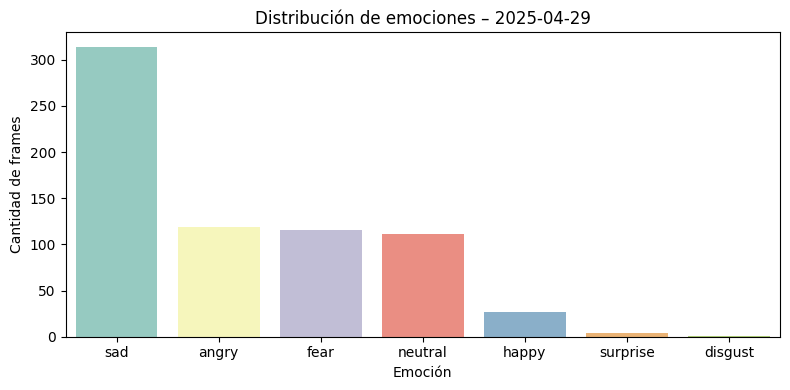

/tmp/ipykernel_31181/3523444102.py:37: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend().remove()


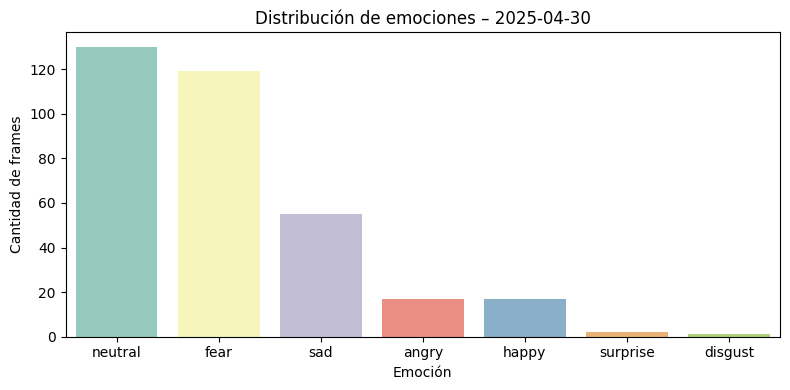

/tmp/ipykernel_31181/3523444102.py:37: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend().remove()


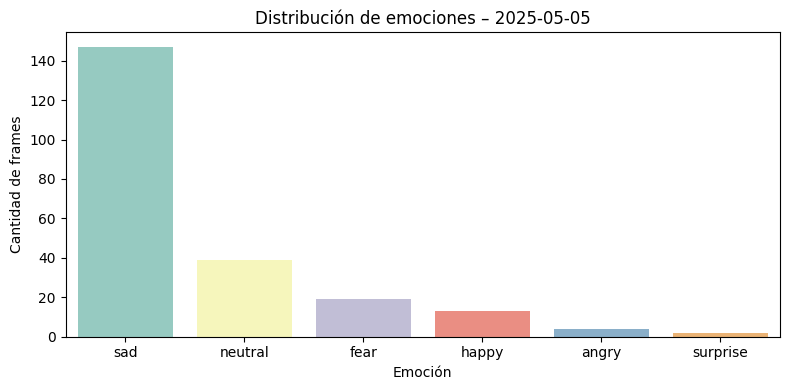

/tmp/ipykernel_31181/3523444102.py:37: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend().remove()


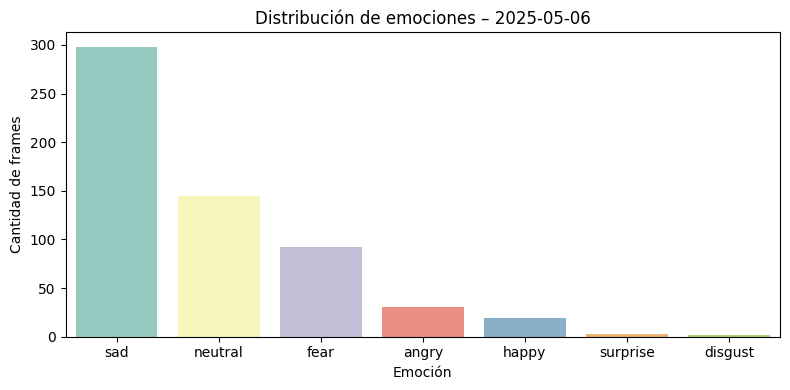

/tmp/ipykernel_31181/3523444102.py:37: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend().remove()


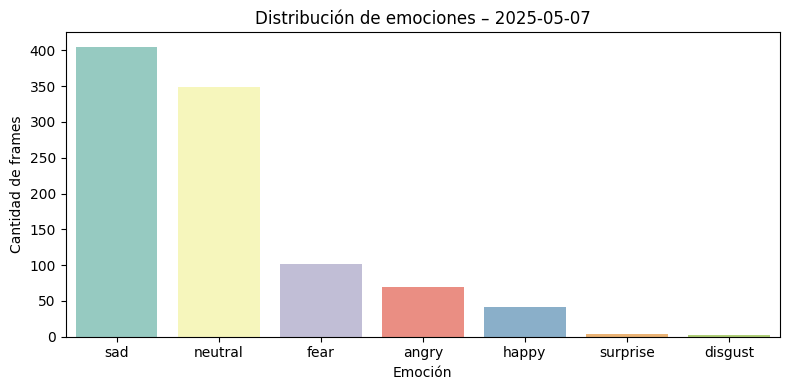

In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from datetime import datetime

def plot_emotion_distribution_by_day(csv_path: str) -> None:
    # Cargar datos
    df = pd.read_csv(csv_path)

    # Convertir timestamp desde el nombre del frame
    df["datetime"] = df["frame"].apply(lambda f: datetime.strptime(f.replace(".jpg", ""), "%Y-%m-%d_%H-%M-%S"))

    # Extraer solo la fecha (sin hora)
    df["date"] = df["datetime"].dt.date

    # Obtener todas las fechas únicas
    dates = df["date"].unique()

    # Crear gráfico por cada fecha
    for date in sorted(dates):
        daily_df = df[df["date"] == date]
        emotion_counts = daily_df["emotion"].value_counts().reset_index()
        emotion_counts.columns = ["emotion", "count"]

        plt.figure(figsize=(8, 4))
        sns.barplot(
            data=emotion_counts,
            x="emotion",
            y="count",
            hue="emotion",
            palette="Set3",
            dodge=False
        )
        plt.title(f"Distribución de emociones – {date}")
        plt.xlabel("Emoción")
        plt.ylabel("Cantidad de frames")
        plt.legend().remove()
        plt.tight_layout()
        plt.show()

plot_emotion_distribution_by_day("emotion_attention_results.csv")